# Statistical Analysis

Objective:
- Perform statistical validation
- Compare theft vs normal patterns
- Identify significant variables
- Validate assumptions for modeling


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller

plt.style.use("ggplot")


In [2]:
df = pd.read_csv("../data/processed/feature_engineered.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()


,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,humidity,hour,day,month,day_of_week,load_ratio,rolling_mean_24h,rolling_std_24h
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,55.189874,0,1,1,0,0.030206,1.408501,0.000000
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,79.649722,1,1,1,0,0.032450,1.499701,0.128977
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,63.687502,2,1,1,0,0.030661,1.513077,0.094097
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,76.549985,3,1,1,0,0.022589,1.438621,0.167564
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,55.590191,4,1,1,0,0.039244,1.577163,0.342094


In [3]:
df.describe()


,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,total_kwh,temperature,humidity,hour,day,month,day_of_week,load_ratio,rolling_mean_24h,rolling_std_24h
count,288000.000000,288000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000,288000.000000
mean,100.500000,2024-01-30 23:30:00,1.825948,229.996506,7.305512,0.920136,0.001830,37.382786,27.396315,65.205688,11.500000,15.516667,1.483333,2.900000,0.050000,1.827764,0.295616
min,1.000000,2024-01-01 00:00:00,0.000000,216.630322,-2.701020,0.850001,0.000000,20.580640,25.086067,50.003716,0.000000,1.000000,1.000000,0.000000,0.000000,0.253456,0.000000
25%,50.750000,2024-01-15 23:45:00,1.253788,227.985155,4.996057,0.885169,0.000000,31.341118,26.339035,57.659334,5.750000,8.000000,1.000000,1.000000,0.034609,1.281669,0.267973
50%,100.500000,2024-01-30 23:30:00,1.834121,229.998999,7.339458,0.920185,0.000000,36.980551,27.506116,65.371083,11.500000,15.500000,1.000000,3.000000,0.050226,1.816706,0.293110
75%,150.250000,2024-02-14 23:15:00,2.426975,232.014360,9.711001,0.955103,0.000000,42.485858,28.512540,72.844528,17.250000,23.000000,2.000000,5.000000,0.063606,2.405156,0.319055
max,200.000000,2024-02-29 23:00:00,3.970118,243.132512,16.270225,0.989999,1.000000,57.766238,29.293820,79.985049,23.000000,31.000000,2.000000,6.000000,0.143241,3.311005,1.135972
std,57.734405,NaN,0.760592,2.997685,3.084552,0.040446,0.042738,7.702231,1.259647,8.798945,6.922199,8.684276,0.499723,1.989141,0.021620,0.701797,0.047371


In [4]:
normal = df[df["theft_label"] == 0]
theft = df[df["theft_label"] == 1]

print("Normal count:", len(normal))
print("Theft count:", len(theft))


Normal count: 287473
Theft count: 527


In [5]:
normal_mean = normal["kwh"].mean()
theft_mean = theft["kwh"].mean()

print("Normal Mean kWh:", normal_mean)
print("Theft Mean kWh:", theft_mean)


Normal Mean kWh: 1.8283190252702786
Theft Mean kWh: 0.5327151046026057


In [6]:
t_stat, p_value = stats.ttest_ind(normal["kwh"], theft["kwh"], equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant difference between theft and normal consumption.")
else:
    print("No significant difference detected.")


T-statistic: 152.95836137547622
P-value: 0.0
Statistically significant difference between theft and normal consumption.


In [7]:
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.var() + group2.var()) / 2)
    return diff / pooled_std

effect_size = cohens_d(normal["kwh"], theft["kwh"])

print("Cohen's d Effect Size:", effect_size)


Cohen's d Effect Size: 2.3398867323869115


In [8]:
stat, p = stats.levene(normal["kwh"], theft["kwh"])

print("Levene Test P-value:", p)

if p < 0.05:
    print("Variances are significantly different.")
else:
    print("No significant variance difference.")


Levene Test P-value: 9.884087704646667e-149
Variances are significantly different.


In [9]:
sample_normal = normal["kwh"].sample(500, random_state=42)
sample_theft = theft["kwh"].sample(min(500, len(theft)), random_state=42)

stat_n, p_n = stats.shapiro(sample_normal)
stat_t, p_t = stats.shapiro(sample_theft)

print("Normal class p-value:", p_n)
print("Theft class p-value:", p_t)


Normal class p-value: 0.0006956625967750722
Theft class p-value: 1.3697334580224815e-10


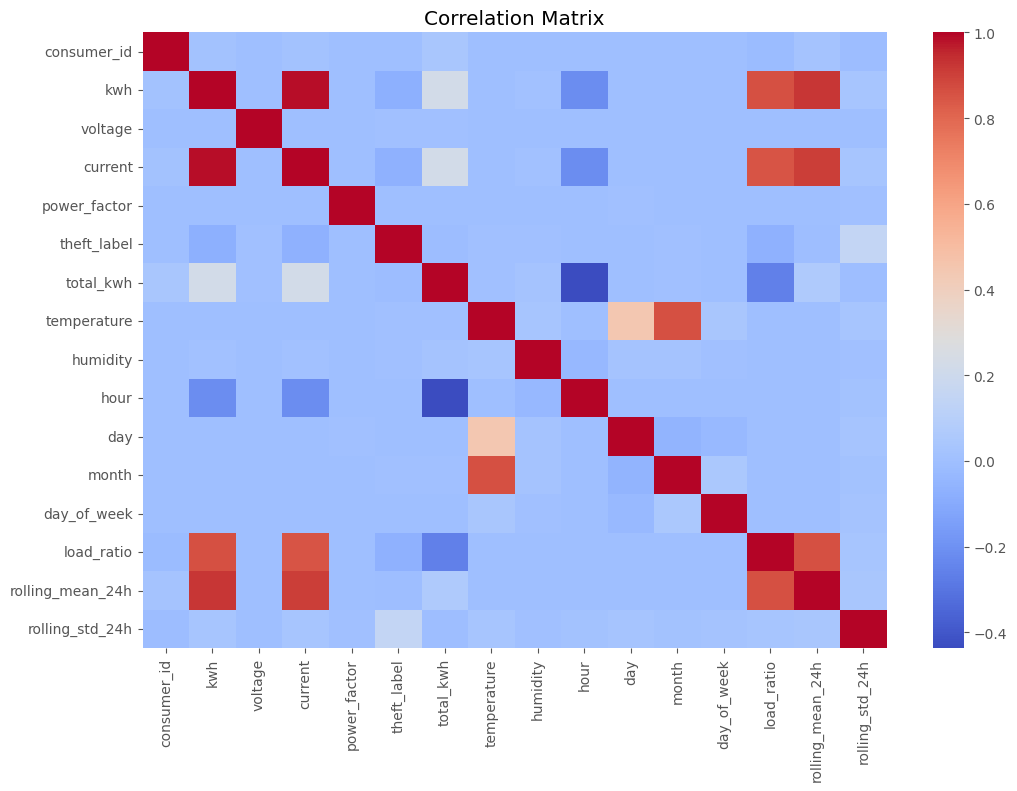

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [11]:
target_corr = corr["theft_label"].sort_values(ascending=False)

print("Correlation with Theft Label:")
print(target_corr)


Correlation with Theft Label:
theft_label         1.000000
rolling_std_24h     0.150165
month               0.002322
humidity            0.002120
voltage             0.001955
temperature         0.001510
power_factor        0.000143
hour               -0.000112
consumer_id        -0.000996
day                -0.001153
day_of_week        -0.001932
rolling_mean_24h   -0.008955
total_kwh          -0.011451
load_ratio         -0.068379
current            -0.071279
kwh                -0.072800
Name: theft_label, dtype: float64


In [12]:
consumer_id = df["consumer_id"].iloc[0]
consumer_data = df[df["consumer_id"] == consumer_id]["kwh"]

adf_result = adfuller(consumer_data)

print("ADF Statistic:", adf_result[0])
print("P-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is NOT stationary.")


ADF Statistic: -7.096682992545496
P-value: 4.2713360608531725e-10
Series is stationary.


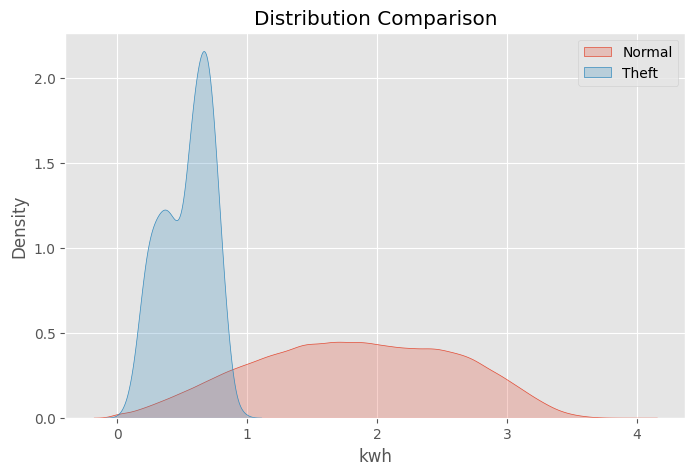

In [13]:
plt.figure(figsize=(8,5))
sns.kdeplot(normal["kwh"], label="Normal", fill=True)
sns.kdeplot(theft["kwh"], label="Theft", fill=True)
plt.legend()
plt.title("Distribution Comparison")
plt.show()


## Key Statistical Findings

1. Theft and normal consumption show statistical differences.
2. Variance patterns differ between classes.
3. Class imbalance confirmed.
4. Some engineered features correlate with theft_label.
5. Time-series may show non-stationarity.

Conclusion:
Statistical evidence supports use of:
- Classification models
- Anomaly detection
- Time-series based modeling
